## 회귀 분석 
- 특정한 값을 찾아내는 과정 ( 기기가 스스로 데이터간의 규칙(연관성, 가중치)을 찾아내는 과정 )

- 성능 평가 지표
    - MAE
        - 실젯값과 예측값의 차이에 절대값으로 평균을 구한 값
    - MSE
        - 실젯값과 예측값의 차이를 제곱한 뒤 평균을 구한 값
    - RMSE
        - MSE에 루트를 씌운 값
    - MSLE
        - MSE 값에 로그를 적용한 값
    - MAPE
        - MAE를 퍼센트로 표시
    - R2 Score
        - 가장 대중적으로 사용하는 성능 평가 지표
        - 1 - (예측에 대한 오차의 제곱) / (평균값의 오차의 제곱)

- 회귀 분석의 순서 
    1. 모델을 선택
    2. 모델 객체(class)를 생성
        - 하이퍼 파라미터(매개변수에 입력이되는 인자 값) 수정
    3. 모델에 학습 ( 독립변수 + 종속변수 )
    4. test 독립변수를 이용하여 예측
    5. 성능 평가 지표를 이용하여 모델의 성능을 확인

In [1]:
# 라이브러리 로드 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
# 모델 로드
from sklearn.linear_model import LinearRegression
# 평가지표 로드 
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, \
                            root_mean_squared_error, mean_absolute_percentage_error, r2_score

In [2]:
# pandas를 이용하여 데이터(boston) 로드 
boston = pd.read_csv("../csv/boston.csv")
boston.head() 

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [3]:
boston.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  Price    506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


- boston data column 설명
    - CRIM : 범죄율 ( 해당 지역 1인당 범죄 발생 수 )
    - ZN : 25000 평방피트 이상 주거지역 비율
    - INDUS : 비상업 영역(상업지구 아닌 지역) 토지 비율
    - CHAS : 찰스강 경계 여부 ( 1: 경계, 0: 비경계 )
    - NOX : 일산화탄소 농도 ( 10ppm 단위 )
    - RM : 주택 1가구당 평균 방의 개수
    - AGE : 1940년 이전의 지어진 주택 비율 ( 건물이 30년 이상의 주택 비율 )
    - DIS : 작업 중심지( 보스턴 5개 중심지 )까지의 가중 거리
    - RAD : 방사형 고속도로 접근성 지수
    - TAX : $10000 당 제산세율
    - PTRATIO : 지역별 학생-교사 비율
    - B : 인종 지수 ( 흑인 거주 비율 )
    - LSTAT : 저소득층 비율 (%)
    - Price : 주택의 가격의 중앙값

In [4]:
# 독립 변수들을 따로 저장 (CHAS, Price를 제외)
X = boston.drop( ['CHAS', 'Price'], axis=1 )
X.head()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [7]:
# 컬럼의 목록에서 특정 원소들을 제외시킨다.
cols = boston.columns.difference( ['CHAS', 'Price'] )

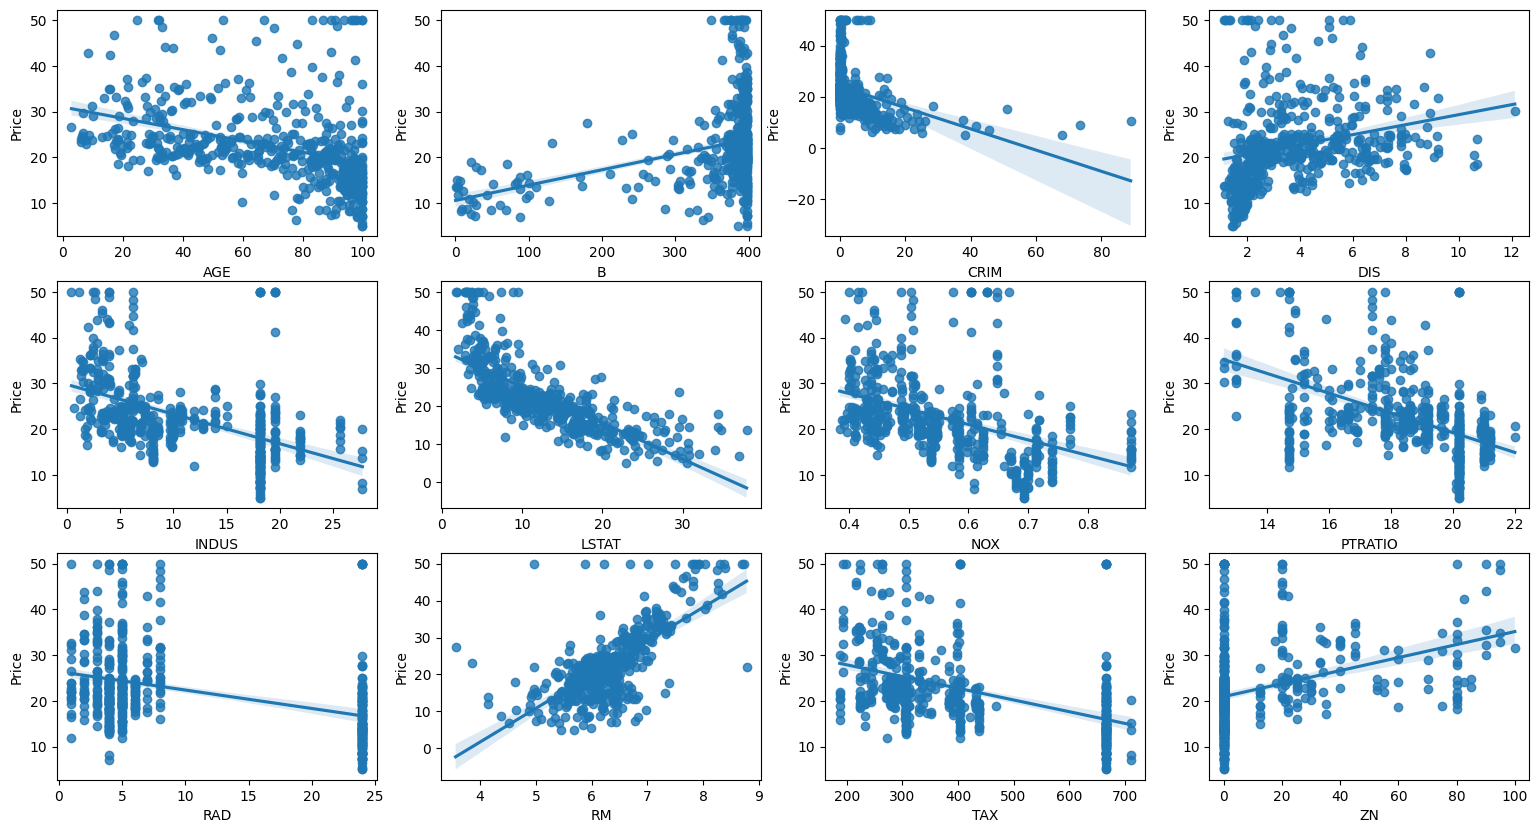

In [8]:
# Price와 독립변수들의 연관성을 그래프로 표시 (산점도 그래프, 회귀선을 표시)

# 12개의 컬럼을 하나의 캔버스에 그린다. 
fig, axes = plt.subplots(3, 4, figsize=(19, 10))

# cols을 기준으로 그래프 생성 
for i in range(len(cols)):
    # i -> index
    sns.regplot( data = boston, x = cols[i], y = 'Price', ax = axes.flat[i] )

plt.show()

In [9]:
# 스케일링이 필요한가? 각 컬럼 간의 데이터의 범위가 큰 차이가 나는가?
# Min Max 확인
X.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


In [10]:
y = boston['Price']

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
# train, test 셋으로 분할 (8:2)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# 종속 변수들의 평균 값 확인 
print(y_train.mean())
print(y_test.mean())

22.796534653465343
21.488235294117644


In [14]:
# 객체 생성
lr = LinearRegression()

In [15]:
# 모델에 학습시킨다 ( 각 컬럼당 가격에 대한 규칙을 찾는 과정 )
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [16]:
# 예측( 문제 풀이 )
pred = lr.predict(X_test)

In [ ]:
pred

In [19]:
y_test

173    23.6
274    32.4
491    13.6
72     22.8
452    16.1
       ... 
412    17.9
436     9.6
411    17.2
86     22.5
75     21.4
Name: Price, Length: 102, dtype: float64

In [20]:
# 실제 정답과 예측값을 비교 
price_df = pd.DataFrame(pred, columns = ['pred price'])
price_df['actual price'] = y_test.values

price_df

,pred price,actual price
0,29.218660,23.6
1,33.551467,32.4
2,14.810658,13.6
3,25.084725,22.8
4,19.173927,16.1
...,...,...
97,-0.520453,17.9
98,13.857699,9.6
99,16.195182,17.2
100,22.248169,22.5


In [21]:
price_df['error'] = price_df['actual price'] - price_df['pred price']

In [22]:
price_df

,pred price,actual price,error
0,29.218660,23.6,-5.618660
1,33.551467,32.4,-1.151467
2,14.810658,13.6,-1.210658
3,25.084725,22.8,-2.284725
4,19.173927,16.1,-3.073927
...,...,...,...
97,-0.520453,17.9,18.420453
98,13.857699,9.6,-4.257699
99,16.195182,17.2,1.004818
100,22.248169,22.5,0.251831


In [24]:
# 실젯값, 예측값을 이용하여 평가 지표 생성
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
# msle = mean_squared_log_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
rmse2 = np.sqrt(mse)

In [25]:
print(f"MAE : {round( mae, 2 )}")
print(f"MSE : {round(mse, 2)}")
print(f"RMSE : {round(rmse, 2)}")
print(f"RMSE2 : {round(rmse2, 2)}")
print(f"MAPE : {round(mape, 2) * 100}%")

MAE : 3.24
MSE : 24.64
RMSE : 4.96
RMSE2 : 4.96
MAPE : 17.0%


In [26]:
r2 = r2_score(y_test, pred)
print(f"R2 Score : {round(r2, 2)}")

R2 Score : 0.66


In [28]:
# 상관계수 출력 
boston.corr().sort_values('Price')

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,Price
LSTAT,0.455621,-0.412995,0.603800,-0.053929,0.590879,-0.613808,0.602339,-0.496996,0.488676,0.543993,0.374044,-0.366087,1.000000,-0.737663
PTRATIO,0.289946,-0.391679,0.383248,-0.121515,0.188933,-0.355501,0.261515,-0.232471,0.464741,0.460853,1.000000,-0.177383,0.374044,-0.507787
INDUS,0.406583,-0.533828,1.000000,0.062938,0.763651,-0.391676,0.644779,-0.708027,0.595129,0.720760,0.383248,-0.356977,0.603800,-0.483725
TAX,0.582764,-0.314563,0.720760,-0.035587,0.668023,-0.292048,0.506456,-0.534432,0.910228,1.000000,0.460853,-0.441808,0.543993,-0.468536
NOX,0.420972,-0.516604,0.763651,0.091203,1.000000,-0.302188,0.731470,-0.769230,0.611441,0.668023,0.188933,-0.380051,0.590879,-0.427321
CRIM,1.000000,-0.200469,0.406583,-0.055892,0.420972,-0.219247,0.352734,-0.379670,0.625505,0.582764,0.289946,-0.385064,0.455621,-0.388305
RAD,0.625505,-0.311948,0.595129,-0.007368,0.611441,-0.209847,0.456022,-0.494588,1.000000,0.910228,0.464741,-0.444413,0.488676,-0.381626
AGE,0.352734,-0.569537,0.644779,0.086518,0.731470,-0.240265,1.000000,-0.747881,0.456022,0.506456,0.261515,-0.273534,0.602339,-0.376955
CHAS,-0.055892,-0.042697,0.062938,1.000000,0.091203,0.091251,0.086518,-0.099176,-0.007368,-0.035587,-0.121515,0.048788,-0.053929,0.175260
DIS,-0.379670,0.664408,-0.708027,-0.099176,-0.769230,0.205246,-0.747881,1.000000,-0.494588,-0.534432,-0.232471,0.291512,-0.496996,0.249929


In [30]:
# CHAS, DIS, B 3개의 컬럼을 제외하고 선형 회귀 모델을 구동하여 평가 지표를 확인(R2score)

X =  boston.drop( ['CHAS', 'DIS', 'B', 'Price'], axis=1 )
y = boston['Price']

# train, test 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()

lr.fit(X_train, y_train)

pred = lr.predict(X_test)

mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
rmse = root_mean_squared_error(y_test, pred)
mape = mean_absolute_percentage_error(y_test, pred)
r2 = r2_score(y_test, pred)

In [31]:
print(f"MAE : {round( mae, 2 )}")
print(f"MSE : {round(mse, 2)}")
print(f"RMSE : {round(rmse, 2)}")
print(f"MAPE : {round(mape, 2) * 100}%")
print(f"R2 Score : {round(r2, 2)}")

MAE : 3.26
MSE : 26.13
RMSE : 5.11
MAPE : 17.0%
R2 Score : 0.64


In [ ]:
sns.scatterplot(boston, x = 'CHAS', y='Price')
plt.show()